# Balkan Cinema — Final Report

In [1]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

---
## 1. Data
One problem in trying to find movies for our data was the lack of a single balkan movie database online.
In order to fix that, we combined several avaible datasets online to create a single balkan movie dataset. The datasets we used were:

Wikidata: https://www.wikidata.org/wiki/Wikidata:WikiProject_Movies

IMDb Non-Commercial Datasets: www.datasets.imdbws.com

Kaggle Movie Dataset (TMDb-based): https://www.kaggle.com/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies

Lumiere Database: www.lumiere.obs.coe.int

One problem we ran into in the beginning was that a lot of movies would appear as Balkan movies just because they were dubbed in a Balkan language, so we had a lot of Hollywood movies included. To fix that, we made sure only movies that are surely produces in a Balkan country (based on original language, region, country of origin etc.). In the end, we ended up with a nice dataset of ~14000 movies. Although there are still some mismatches, in general all the movies are authentic Balkan movies produced form 1945-2025.

---
## 2. Analyzing Trends in Balkan Cinematography Through the Years

Balkan cinematography has a reach history that spends several periods. By grouping the films by the year they were made, we can find out the quantity of movies produced each year and how that changes over time.

We can see a clear rise of movie production throughout the 60's and 70's, dubbed the "golden age" of Balkan cinema. During these times, the mostly communist governments of the Balkans, including Yugoslavia, Romania, Bulgaria and Albania invested heavily in the movie industry to try and enforce national identity, and many of these movies were used for propaganda reasons, and a lot of movies were based on WW2 partisan liberation wars.

There is also a clear drop of movies after 1990, coinciding with the fall of communism and the wars that hindered movie production.

After stabilizing, the movie production went back to a healthy amount and even surpassed the pre-war production.

In [2]:
df_prod = pd.read_csv('data/balkan_movies_confirmed.csv')
df_prod = df_prod.dropna(subset=['year_final'])
df_prod['year'] = df_prod['year_final'].astype(int)
df_prod = df_prod[(df_prod['year'] >= 1945) & (df_prod['year'] <= 2024)]

def primary_country(val):
    if pd.isna(val):
        return None
    for sep in ['|', ',']:
        if sep in val:
            return val.split(sep)[0].strip()
    return val.strip()

df_prod['primary_country'] = df_prod['country'].apply(primary_country)

BALKAN_COUNTRIES = [
    'Albania', 'Bosnia and Herzegovina', 'Bulgaria', 'Croatia',
    'Greece', 'Kosovo', 'Montenegro', 'North Macedonia', 'Romania',
    'Serbia', 'Slovenia', 'Yugoslavia'
]
NAME_MAP = {
    "People's Republic of Bulgaria": 'Bulgaria',
    'Macedonia': 'North Macedonia',
    'Serbia and Montenegro': 'Serbia',
}
df_prod['primary_country'] = df_prod['primary_country'].replace(NAME_MAP)
df_balkan_prod = df_prod[df_prod['primary_country'].isin(BALKAN_COUNTRIES)].copy()

country_order = df_balkan_prod['primary_country'].value_counts().index.tolist()
palette = sns.color_palette('tab10', n_colors=len(country_order))
color_map = dict(zip(country_order, palette))
all_years = range(df_balkan_prod['year'].min(), df_balkan_prod['year'].max() + 1)

print(f'Films loaded: {len(df_balkan_prod)}')

Films loaded: 12440


### Graph 1 — Total Films Produced per Year

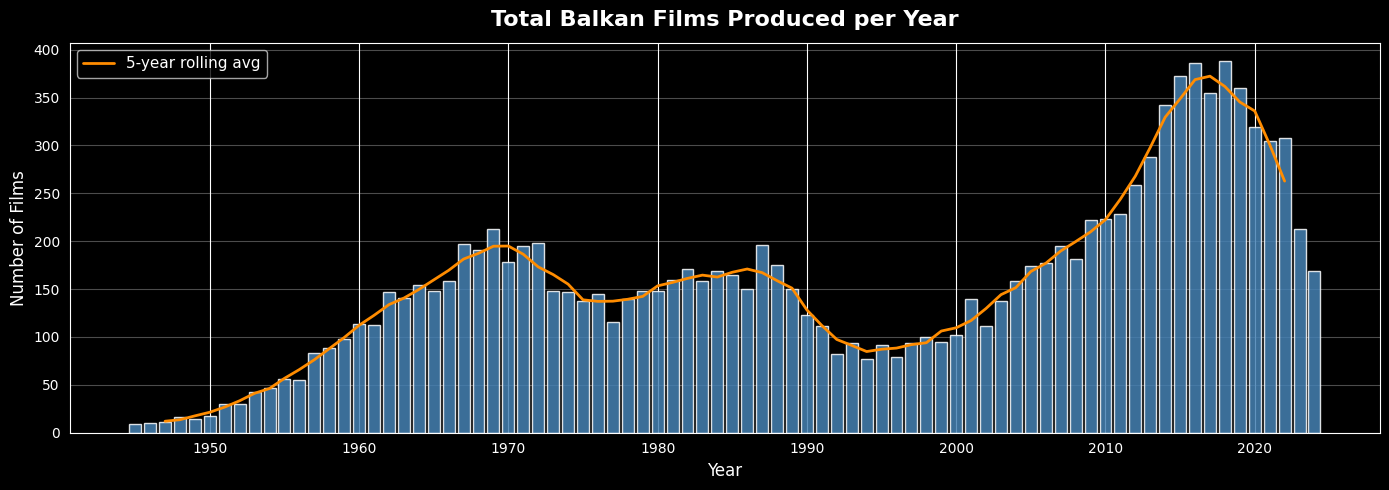

In [3]:
films_per_year = df_balkan_prod.groupby('year').size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(films_per_year['year'], films_per_year['count'], color='steelblue', width=0.8, alpha=0.85)
rolling = films_per_year.set_index('year')['count'].rolling(5, center=True).mean()
ax.plot(rolling.index, rolling.values, color='darkorange', linewidth=2, label='5-year rolling avg')
ax.set_title('Total Balkan Films Produced per Year', fontsize=16, fontweight='bold', pad=12)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Films', fontsize=12)
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
ax.xaxis.set_minor_locator(mticker.MultipleLocator(5))
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('graphs/total_films_per_year.png', dpi=150, bbox_inches='tight')
plt.show()

### Graph 2 — Films per Year by Country

That trend can be seen in almost all coutries.

By visualizing the data, the fall of communism becomes very clear.

You can also see clearly how ex-Yugoslav countries start producing their own movies after the fall, how Yugoslav movies stop after 1991, and other interesting events like the fall of the millatary junta in Greece in the 1970's.

The fact that all these historic events can be clearly seen though movie production is very interesting and telling of how connected culture and politics really are.

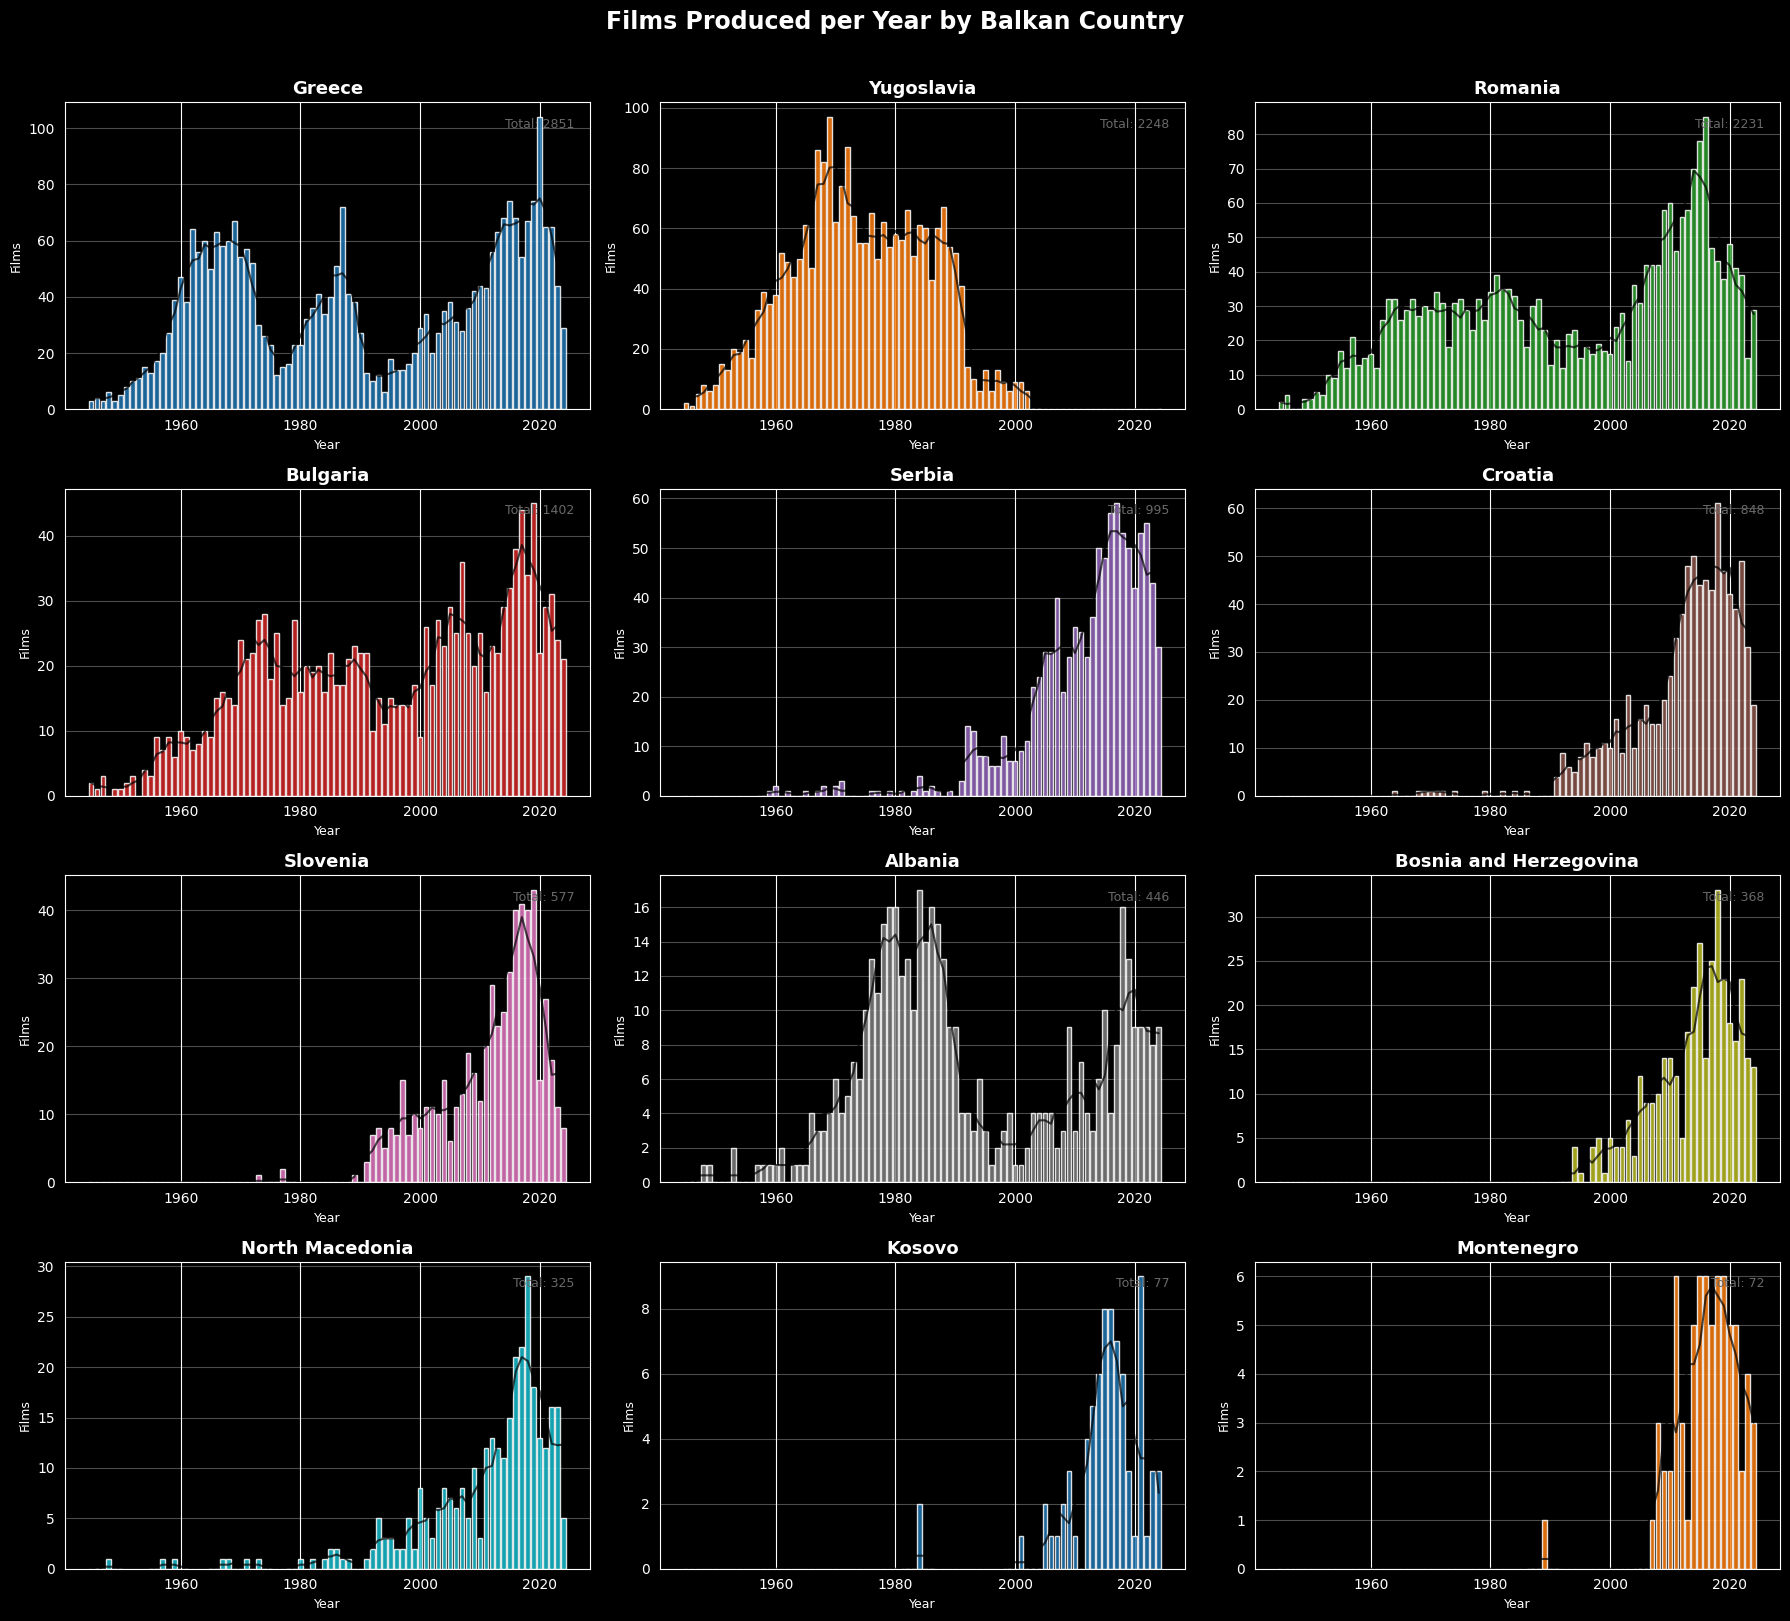

In [4]:
n_cols = 3
n_rows = -(-len(country_order) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4), sharey=False)
axes = axes.flatten()

for i, country in enumerate(country_order):
    ax = axes[i]
    subset = df_balkan_prod[df_balkan_prod['primary_country'] == country]
    counts = subset.groupby('year').size().reindex(all_years, fill_value=0)
    ax.bar(counts.index, counts.values, color=color_map[country], width=0.8, alpha=0.85)
    if counts.sum() >= 10:
        roll = counts.rolling(5, center=True, min_periods=2).mean()
        ax.plot(roll.index, roll.values, color='black', linewidth=1.5, alpha=0.7)
    ax.set_title(country, fontsize=13, fontweight='bold')
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('Films', fontsize=9)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(20))
    ax.grid(axis='y', alpha=0.3)
    ax.annotate(f'Total: {counts.sum()}', xy=(0.97, 0.95), xycoords='axes fraction',
                ha='right', va='top', fontsize=9, color='dimgray')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Films Produced per Year by Balkan Country', fontsize=17, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('graphs/films_per_year_by_country.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Analysis of Genres of Balkan Films

We grouped Balkan movies by their genre in order to determine the top genres. It can be clearly seen that drama completely dominates.

This is a global trend as drama is a very broad genre that includes a lot of different sub-genres, but another explanation is that a lot of the war movies of the 60's and 70's were labelled as drama because they also tened to follow some side-plot, usually a romance story of a soldier or the death of a family member in the war, and these made these war movies fit into drama as well.

In [6]:
df_genre_raw = pd.read_csv('data/balkan_movies_confirmed.csv')
df_genre_raw = df_genre_raw.dropna(subset=['genres_final', 'country'])

# Explode multi-country entries so each country gets its own row
df_genre_raw['country_single'] = df_genre_raw['country'].str.split(',')
df_genre_raw = df_genre_raw.explode('country_single')
df_genre_raw['country_single'] = df_genre_raw['country_single'].str.strip()

BALKAN_GENRE = [
    'Albania', 'Bosnia and Herzegovina', 'Bulgaria', 'Croatia',
    'Greece', 'Kosovo', 'Montenegro', 'North Macedonia',
    'Romania', 'Serbia', 'Slovenia', 'Yugoslavia', 'Macedonia'
]
df_balkan_genre = df_genre_raw[df_genre_raw['country_single'].isin(BALKAN_GENRE)].copy()
df_balkan_genre['country_single'] = df_balkan_genre['country_single'].replace('Macedonia', 'North Macedonia')

# Explode genres
df_balkan_genre['genre_single'] = df_balkan_genre['genres_final'].str.split(',')
df_balkan_genre = df_balkan_genre.explode('genre_single')
df_balkan_genre['genre_single'] = df_balkan_genre['genre_single'].str.strip()

print(f'Genre rows: {len(df_balkan_genre)}')

Genre rows: 15299


### Graph 1 — Top 10 Most Popular Genres Overall

/tmp/ipykernel_9234/2511463475.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_overall.values, y=top_10_overall.index, palette='viridis')


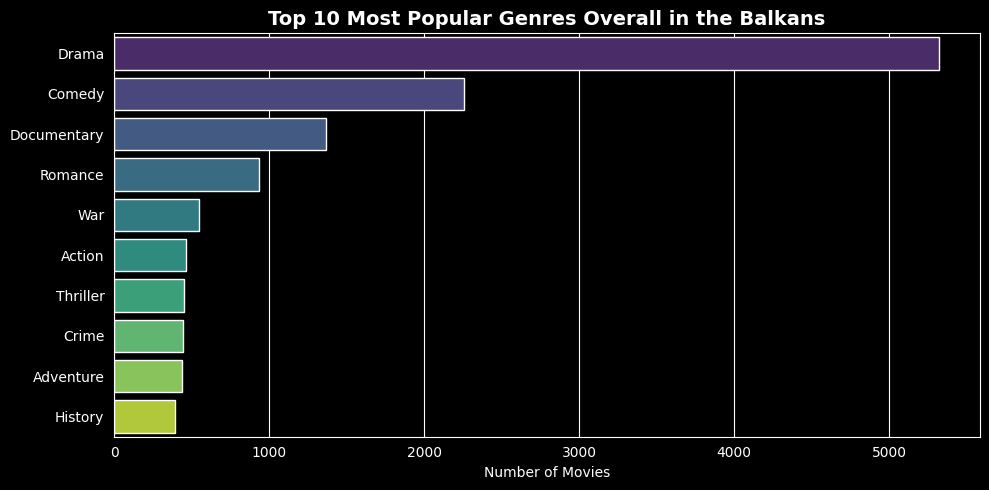

In [7]:
top_10_overall = df_balkan_genre['genre_single'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_10_overall.values, y=top_10_overall.index, palette='viridis')
plt.title('Top 10 Most Popular Genres Overall in the Balkans', fontsize=14, fontweight='bold')
plt.xlabel('Number of Movies')
plt.ylabel('')
plt.tight_layout()
plt.savefig('graphs/top10_genres_overall.png', dpi=150, bbox_inches='tight')
plt.show()

### Graph 2 — Top 5 Genres per Balkan Country

The same trend of drama dominating can be seen in every individual country.

/tmp/ipykernel_9234/3555296557.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, ax=ax, palette='mako')
/tmp/ipykernel_9234/3555296557.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, ax=ax, palette='mako')
/tmp/ipykernel_9234/3555296557.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, ax=ax, palette='mako')
/tmp/ipykernel_9234/3555296557.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is dep

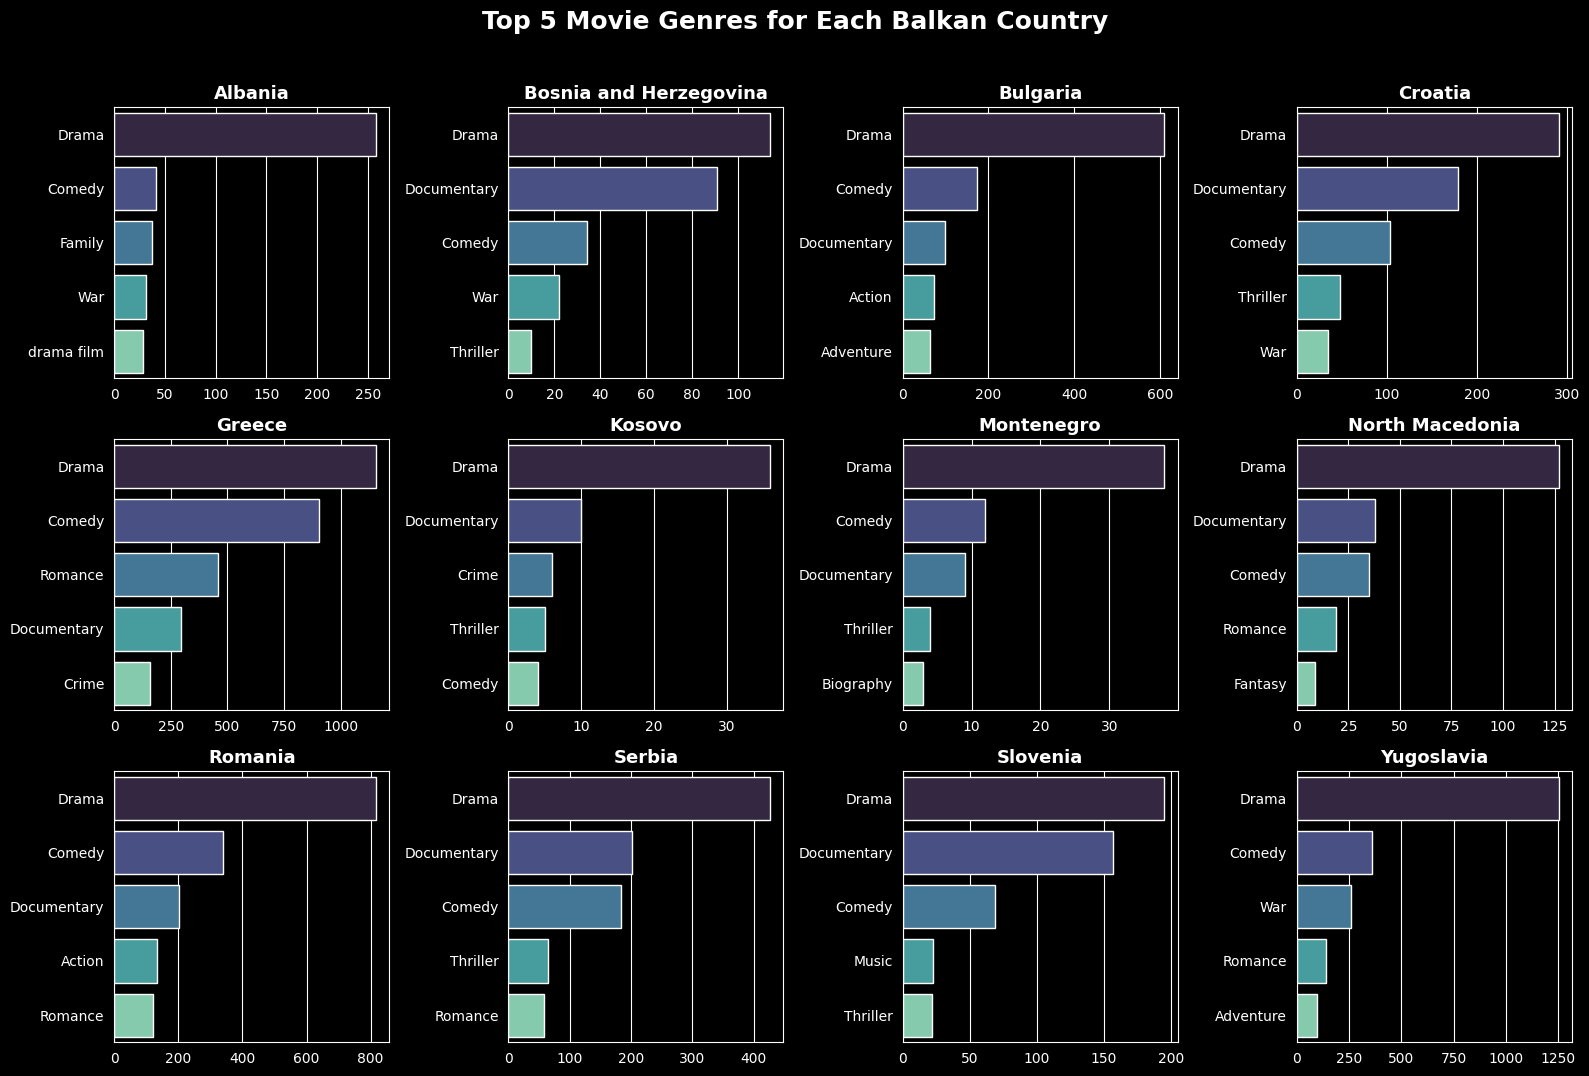

In [8]:
unique_countries_g = sorted(df_balkan_genre['country_single'].unique())
cols = 4
rows = math.ceil(len(unique_countries_g) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 3.5 * rows))
axes = axes.flatten()

for i, country in enumerate(unique_countries_g):
    ax = axes[i]
    country_data = df_balkan_genre[df_balkan_genre['country_single'] == country]
    top_genres = country_data['genre_single'].value_counts().head(5)
    sns.barplot(x=top_genres.values, y=top_genres.index, ax=ax, palette='mako')
    ax.set_title(country, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

for j in range(len(unique_countries_g), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Top 5 Movie Genres for Each Balkan Country', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graphs/top5_genres_per_country.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Ratings and Popularity of Balkan Movies

Determining the ratings of Balkan movies was a very tricky task, mainly because we had a lot of missing data, especially about older movies.

Also there just isn't enough data for some countries. Countries like Bosnia, Kosovo and North Macedonia have very few movies with very few ratings. This results in skewing as countries with 20 movies are heavily influenced by ratings of individual movies and the average doesn't mean much. Greece in particular tends to suffer the most because it has so many ratings. We suppose it is suffering from success.

So these findings should be taken with a grain of salt, although they still show interesting results.

In [10]:
df_ratings_raw = pd.read_csv('data/balkan_movies_confirmed.csv')

BALKAN_RATINGS = [
    'Romania', 'Greece', 'Yugoslavia', 'Serbia', 'Albania',
    'Bulgaria', 'Croatia', 'Slovenia', 'Bosnia and Herzegovina',
    'North Macedonia', 'Kosovo', 'Montenegro'
]
movies = df_ratings_raw[df_ratings_raw['country'].isin(BALKAN_RATINGS)].copy()

COUNTRY_COLORS = {
    'Albania':                 '#9a1107',
    'Bosnia and Herzegovina':  '#f4ff39',
    'Bulgaria':                '#2dbb25',
    'Croatia':                 '#225f9a',
    'Greece':                  '#00c0ff',
    'Kosovo':                  '#8f5471',
    'Montenegro':              '#ff6363',
    'North Macedonia':         '#eb624b',
    'Romania':                 '#e67e22',
    'Serbia':                  '#213986',
    'Slovenia':                '#f58fe0',
    'Yugoslavia':              '#003DA5',
}
print(f'Single-country Balkan movies: {len(movies)}')

Single-country Balkan movies: 11966


### Graph 1 — Average IMDb Rating by Country

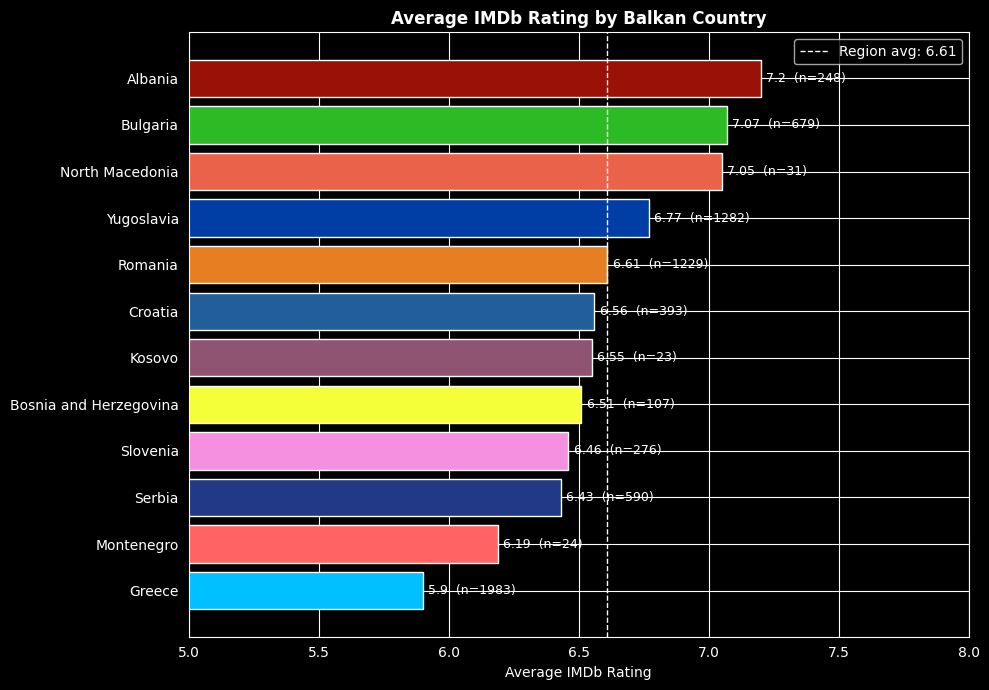

In [11]:
imdb_ratings = (
    movies[movies['imdb_rating'].notna()]
    .groupby('country')
    .agg(avg_imdb_rating=('imdb_rating', 'mean'), num_rated_movies=('imdb_rating', 'count'))
    .round(2)
    .sort_values('avg_imdb_rating', ascending=True)
    .reset_index()
)
colors = [COUNTRY_COLORS.get(c, 'gray') for c in imdb_ratings['country']]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(imdb_ratings['country'], imdb_ratings['avg_imdb_rating'], color=colors)
ax.axvline(x=imdb_ratings['avg_imdb_rating'].mean(), color='white', linestyle='--', linewidth=1,
           label=f"Region avg: {imdb_ratings['avg_imdb_rating'].mean():.2f}")
ax.set_xlim(5, 8)
for bar, val, n in zip(bars, imdb_ratings['avg_imdb_rating'], imdb_ratings['num_rated_movies']):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val}  (n={n})', va='center', fontsize=9)
ax.set_xlabel('Average IMDb Rating')
ax.set_title('Average IMDb Rating by Balkan Country', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('graphs/ratings_combined.png', dpi=150, bbox_inches='tight')
plt.show()

### Graph 2 — Popularity by Country (Total IMDb Votes)

It can be easily seen that movies with higher population, richer cinematographic tradition and a better cinematographic industry tend to have more ratings. Standing out especially are Greece and Romania, which both have produced movies that have been critically acclaimed internationally and have received awards.

Slovenia is a country punching above it's weight in both ratings and votes, especially considering it's population size and relatively new film industry as an indpepended country.

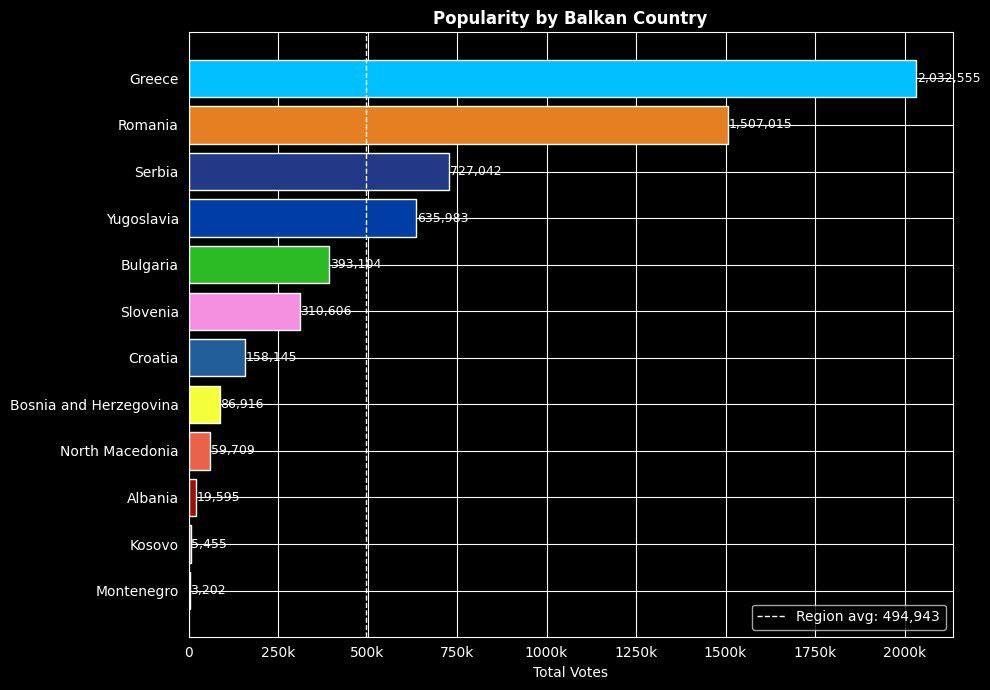

In [12]:
popularity = (
    movies[movies['imdb_votes'].notna()]
    .groupby('country')
    .agg(total_votes=('imdb_votes', 'sum'), avg_imdb_votes=('imdb_votes', 'mean'))
    .round(0)
    .sort_values('total_votes', ascending=True)
    .reset_index()
)
colors = [COUNTRY_COLORS.get(c, 'gray') for c in popularity['country']]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(popularity['country'], popularity['total_votes'], color=colors)
ax.axvline(x=popularity['total_votes'].mean(), color='white', linestyle='--', linewidth=1,
           label=f"Region avg: {int(popularity['total_votes'].mean()):,}")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k' if x >= 1000 else str(int(x))))
for bar, val in zip(bars, popularity['total_votes']):
    ax.text(val + 2000, bar.get_y() + bar.get_height()/2, f'{int(val):,}', va='center', fontsize=9)
ax.set_xlabel('Total Votes')
ax.set_title('Popularity by Balkan Country', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('graphs/popularity_combined.png', dpi=150, bbox_inches='tight')
plt.show()

### Graph 4 — Top 5 Highest Rated Movies per Country (≥350 votes)

Many of these movies are childhood classics of people that grew up in the Balkans.

We have to acknowledge that the results are somewhat dubious, again because some countries just don't have enough movies with a lot of ratings, so results tend to be skewed. We made sure to include movies with more than 350 ratings, and some countries don't even have 5 of those.

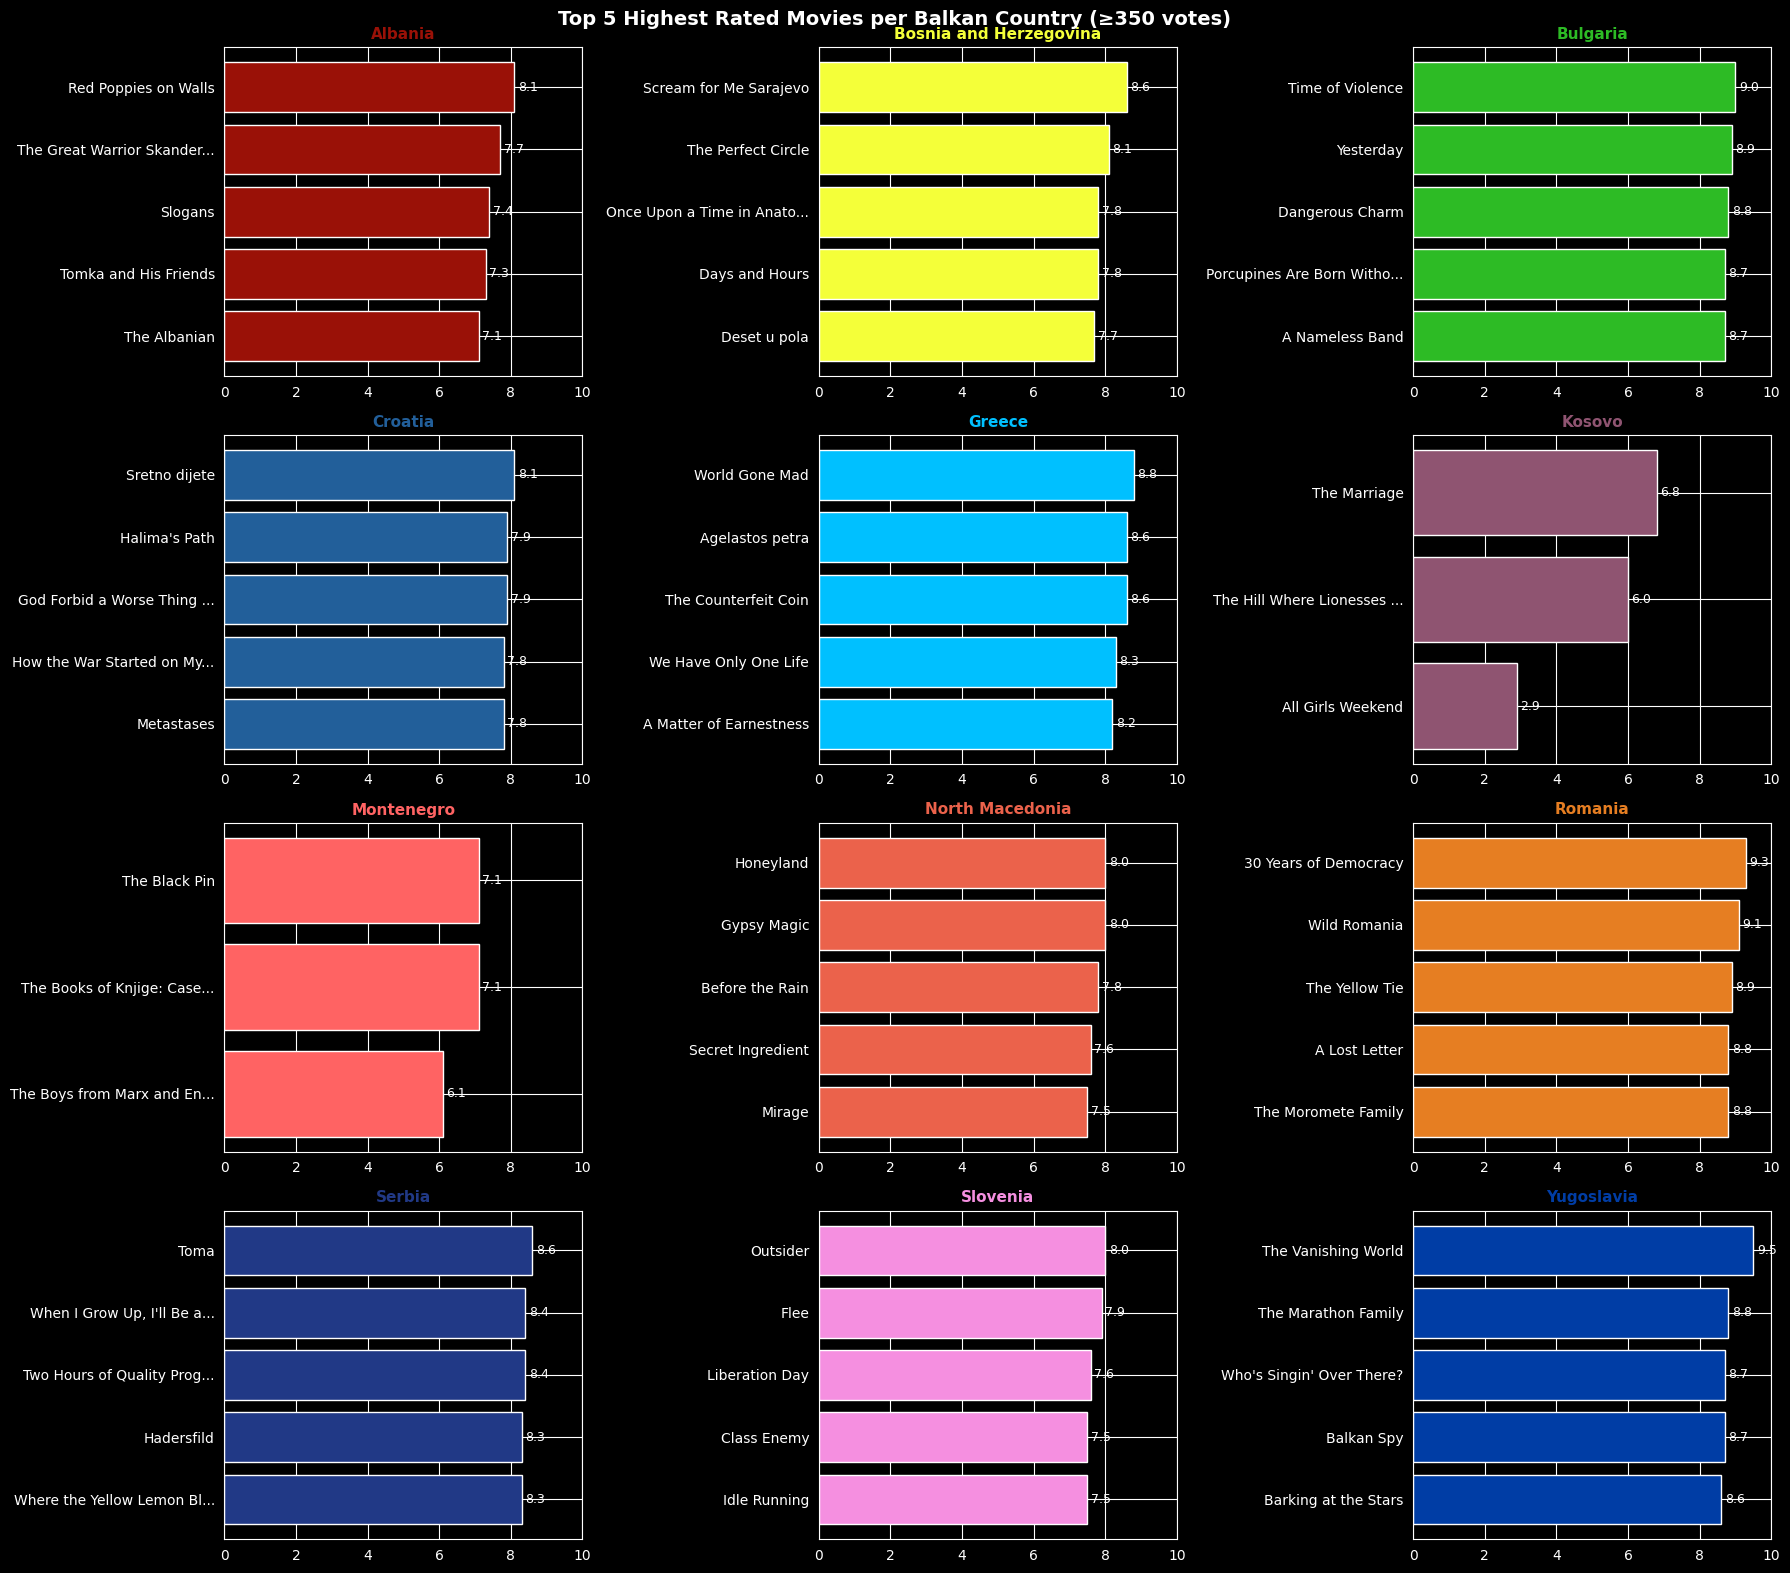

In [13]:
top_rated = (
    movies[(movies['imdb_rating'].notna()) & (movies['imdb_votes'] >= 350)]
    .sort_values('imdb_rating', ascending=False)
    .groupby('country')
    .head(5)
    .sort_values(['country', 'imdb_rating'], ascending=[True, False])
)
countries_r = sorted(top_rated['country'].unique())
n_cols = 3
n_rows = -(-len(countries_r) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, country in enumerate(countries_r):
    ax = axes[i]
    data = top_rated[top_rated['country'] == country]
    labels = [t[:25] + '...' if len(t) > 25 else t for t in data['title_final']]
    color = COUNTRY_COLORS.get(country, 'gray')
    bars = ax.barh(labels, data['imdb_rating'], color=color)
    ax.set_xlim(0, 10)
    ax.set_title(country, fontsize=11, fontweight='bold', color=color)
    ax.invert_yaxis()
    for bar, val in zip(bars, data['imdb_rating']):
        ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val}', va='center', fontsize=9)

for j in range(len(countries_r), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Top 5 Highest Rated Movies per Balkan Country (≥350 votes)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('graphs/top5_rated_combined.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Clustering and Finding "Hidden Gems"

One problem we wanted to research is why Balkan cinematography is generally underrepresented in the world.

One idea we had was to "group" movies into clusters based on their popularity and score. We found 3 groups:

#### Group A – Blockbusters : votes > 1 000  AND  rating > 7.5
#### Group B – Hidden Gems  : 300 < votes < 500  AND  rating > 7.0
#### Group C – Flops        : votes > 800   AND  rating < 6.0


We found a lot of what we call "Hidden Gems". Very good movies with consistent high ratings from the users, that just are not that popular. Movies in this category include:

Name                                    County      Rating  Nr. Votes

The Vanishing World                  │ Yugoslavia │ 9.5    │ 391

Palace 176                           │ Albania    │ 9.4    │ 307

Wild Romania                         │ Romania    │ 9.1    │ 411

A Lost Letter                        │ Romania    │ 8.8    │ 453

Porcupines Are Born Without Bristles │ Bulgaria   │ 8.7    │ 485

Idle Running                         │ Slovenia   │ 8.5    │ 422


In [14]:
df_km = pd.read_csv('data/balkan_movies_confirmed.csv')

BALKAN_KM = [
    'Romania', 'Greece', 'Yugoslavia', 'Serbia', 'Albania',
    'Bulgaria', 'Croatia', 'Slovenia', 'Bosnia and Herzegovina',
    'North Macedonia', 'Kosovo', 'Montenegro'
]
movies_km = (
    df_km[df_km['country'].isin(BALKAN_KM)]
    .dropna(subset=['imdb_votes', 'imdb_rating'])
    .copy()
)

# Threshold-based group selection
# Group A – Blockbusters : votes > 1 000  AND  rating > 7.5
# Group B – Hidden Gems  : 300 < votes < 500  AND  rating > 7.0
# Group C – Flops        : votes > 800   AND  rating < 6.0
mask_A = (movies_km['imdb_votes'] > 1000) & (movies_km['imdb_rating'] > 7.5)
mask_B = (movies_km['imdb_votes'] > 300)  & (movies_km['imdb_votes'] < 500) & (movies_km['imdb_rating'] > 7.0)
mask_C = (movies_km['imdb_votes'] > 800)  & (movies_km['imdb_rating'] < 6.0)

pool = movies_km[mask_A | mask_B | mask_C].copy()
pool['true_group'] = 'A'
pool.loc[mask_B[pool.index], 'true_group'] = 'B'
pool.loc[mask_C[pool.index], 'true_group'] = 'C'

print(f'A – Blockbusters : {mask_A.sum()}')
print(f'B – Hidden Gems  : {mask_B.sum()}')
print(f'C – Flops        : {mask_C.sum()}')

A – Blockbusters : 196
B – Hidden Gems  : 135
C – Flops        : 161


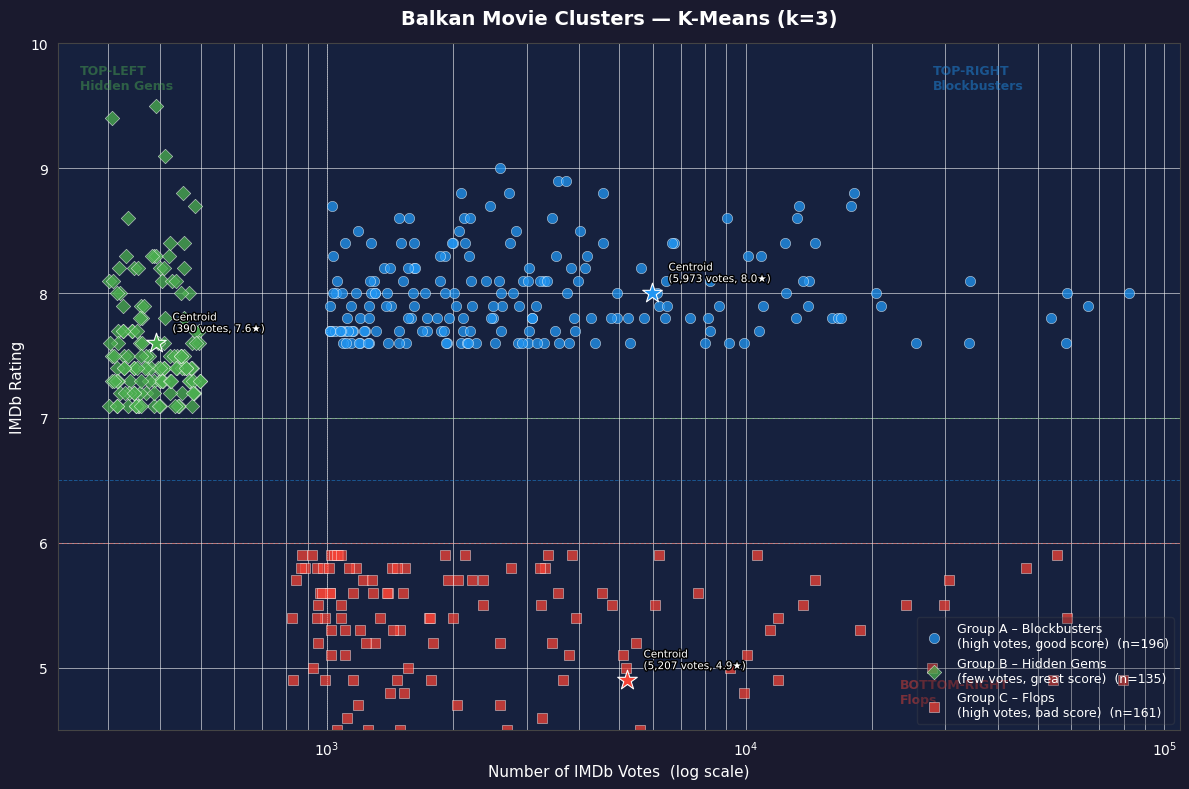

In [15]:
X = pool[['imdb_votes', 'imdb_rating']].copy()
X['log_votes'] = np.log10(X['imdb_votes'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[['log_votes', 'imdb_rating']])
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
pool['cluster'] = kmeans.fit_predict(X_scaled)

# Color by threshold group (not K-Means cluster) to avoid cross-region drift
TRUE_NAMES = {'A': 'Blockbusters', 'B': 'Hidden Gems', 'C': 'Flops'}
pool['group_label'] = pool['true_group'].map(TRUE_NAMES)

centroids = (
    pool.groupby('group_label')[['imdb_votes', 'imdb_rating']]
    .mean().round(1)
)

GROUP_CFG = {
    'Blockbusters': dict(color='#2196F3', marker='o', label='Group A – Blockbusters\n(high votes, good score)'),
    'Hidden Gems':  dict(color='#4CAF50', marker='D', label='Group B – Hidden Gems\n(few votes, great score)'),
    'Flops':        dict(color='#F44336', marker='s', label='Group C – Flops\n(high votes, bad score)'),
}

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#16213e')

for group, cfg in GROUP_CFG.items():
    sub = pool[pool['group_label'] == group]
    ax.scatter(
        sub['imdb_votes'], sub['imdb_rating'],
        c=cfg['color'], marker=cfg['marker'],
        s=55, alpha=0.75, linewidths=0.4, edgecolors='white',
        label=f"{cfg['label']}  (n={len(sub)})"
    )

for gname, cfg in GROUP_CFG.items():
    cx = centroids.loc[gname, 'imdb_votes']
    cy = centroids.loc[gname, 'imdb_rating']
    ax.scatter(cx, cy, c=cfg['color'], s=220, marker='*',
               edgecolors='white', linewidths=0.8, zorder=5)
    ax.annotate(
        f'Centroid\n({int(cx):,} votes, {cy:.1f}★)',
        xy=(cx, cy), xytext=(12, 8), textcoords='offset points',
        fontsize=7.5, color='white',
        path_effects=[pe.withStroke(linewidth=2, foreground='black')]
    )

ax.axhline(y=7.0, color='#4CAF50', linewidth=0.7, linestyle='--', alpha=0.45)
ax.axhline(y=6.5, color='#2196F3', linewidth=0.7, linestyle='--', alpha=0.45)
ax.axhline(y=6.0, color='#F44336', linewidth=0.7, linestyle='--', alpha=0.45)
ax.axvline(x=1000, color='white', linewidth=0.6, linestyle=':', alpha=0.3)

corner_kw = dict(fontsize=9, fontweight='bold', alpha=0.45, transform=ax.transAxes)
ax.text(0.02, 0.97, 'TOP-LEFT\nHidden Gems',   color='#4CAF50', va='top', **corner_kw)
ax.text(0.78, 0.97, 'TOP-RIGHT\nBlockbusters',  color='#2196F3', va='top', **corner_kw)
ax.text(0.75, 0.04, 'BOTTOM-RIGHT\nFlops',      color='#F44336', **corner_kw)

ax.set_xscale('log')
ax.set_xlabel('Number of IMDb Votes  (log scale)', color='white', fontsize=11)
ax.set_ylabel('IMDb Rating', color='white', fontsize=11)
ax.set_title('Balkan Movie Clusters — K-Means (k=3)', color='white',
             fontsize=14, fontweight='bold', pad=14)
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('#444')
ax.grid(True, which='both', color='#ffffff22', linewidth=0.4)
ax.set_ylim(4.5, 10)
ax.legend(loc='lower right', framealpha=0.25,
          facecolor='#1a1a2e', edgecolor='#555', labelcolor='white', fontsize=9)

plt.tight_layout()
plt.savefig('graphs/balkan_kmeans_clusters.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

---
## 6. Average Movie Rating per Year by Era

An interesting result we found was when we had the idea to group the movies by historical eras. We had the idea to take the average rating of each year, and then the average rating of the whole era as well, to try and see any trends in movie quality.

To our surprise, we find that the ratings haven't really changed. You can see a slight bump during the 70's and a small decrease during the 2010's, but otherwise the average ratings tends to stay the same through every age.

A reason for this may be the low number of ratings, outliers or the fact that people tend to rate movies the same way without much thought, since a cinephile class doesn't really exist in the Balkans, so there's not much thought behind the ratings.

Another theory may be that the quality of movies really just hasn't improved. The limited budget and lack of international recognition limits Balkan movie quality.

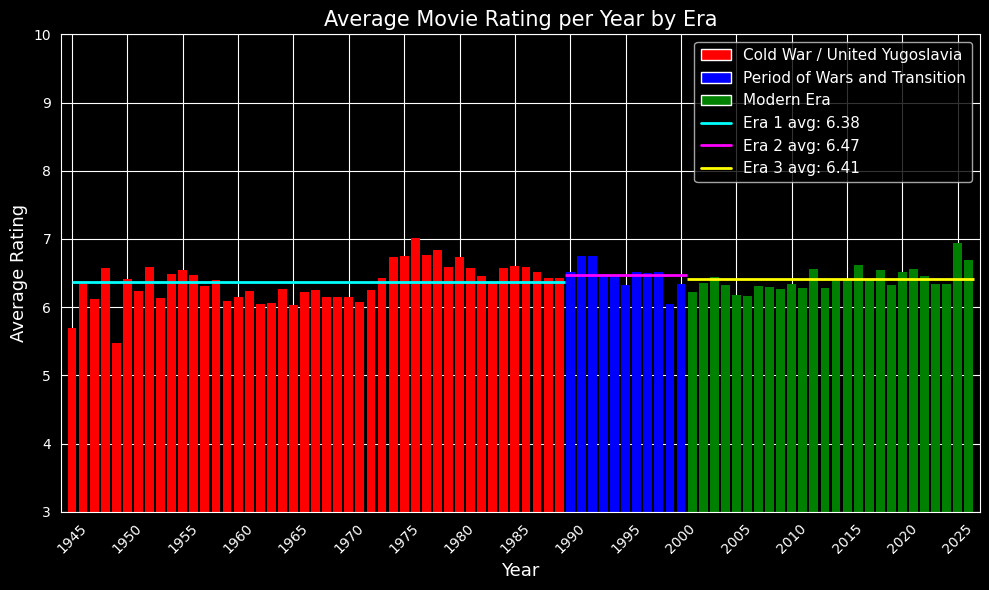

In [17]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

df_era = pd.read_csv('data/balkan_movies_confirmed.csv')
df_era['rating'] = df_era['imdb_rating'].combine_first(df_era['tmdb_rating'])
df_era = df_era.dropna(subset=['year_final', 'rating'])
df_era = df_era[df_era['rating'] >= 0.5]
df_era['year'] = df_era['year_final'].astype(int)

avg_per_year = df_era.groupby('year')['rating'].mean()
all_years_era = np.arange(1945, avg_per_year.index.max() + 1)
avg_per_year = avg_per_year.reindex(all_years_era)

def era_color(year):
    if year <= 1989:
        return 'red'
    elif year <= 2000:
        return 'blue'
    else:
        return 'green'

colors_era = [era_color(y) for y in all_years_era]

era1_avg = df_era[df_era['year'] < 1990]['rating'].mean()
era2_avg = df_era[(df_era['year'] >= 1990) & (df_era['year'] < 2001)]['rating'].mean()
era3_avg = df_era[df_era['year'] >= 2001]['rating'].mean()

Y_MIN = 3
fig, ax = plt.subplots(figsize=(10, 6))
for year, val, color in zip(all_years_era, avg_per_year, colors_era):
    if not np.isnan(val):
        ax.bar(year, val - Y_MIN, color=color, width=0.8, edgecolor='none', bottom=Y_MIN)

ax.hlines(era1_avg, 1945,             1989.5,               colors='cyan',    linewidths=2)
ax.hlines(era2_avg, 1989.5,           2000.5,               colors='magenta', linewidths=2)
ax.hlines(era3_avg, 2000.5,           all_years_era[-1]+0.5, colors='yellow',  linewidths=2)

ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Average Rating', fontsize=13)
ax.set_title('Average Movie Rating per Year by Era', fontsize=15)
ax.set_xlim(1944, all_years_era[-1] + 1)
ax.set_ylim(Y_MIN, 10)
ax.set_xticks(np.arange(1945, all_years_era[-1] + 1, 5))
ax.tick_params(axis='x', rotation=45)

legend_elements = [
    Patch(facecolor='red',     label='Cold War / United Yugoslavia'),
    Patch(facecolor='blue',    label='Period of Wars and Transition'),
    Patch(facecolor='green',   label='Modern Era'),
    Line2D([0], [0], color='cyan',    linewidth=2, label=f'Era 1 avg: {era1_avg:.2f}'),
    Line2D([0], [0], color='magenta', linewidth=2, label=f'Era 2 avg: {era2_avg:.2f}'),
    Line2D([0], [0], color='yellow',  linewidth=2, label=f'Era 3 avg: {era3_avg:.2f}'),
]
ax.legend(handles=legend_elements, fontsize=11)

plt.tight_layout()
plt.savefig('graphs/avg_rating_by_era.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Conclusions

Since all three of our members are form the Balkans, and our Erasmus is in Slovenia, we wanted to pick a subject that we could all relate to. There are several topics for the Balkans that we could've chosen, but in the end we decided on cinematography specifically to see how it relates to history and politics, and why it remains so underdeveloped as an industry.

Our findings present interesting results. How the propaganda of communism and communist cinematography influenced Balkan movies in the Cold War, how the destructive wars and revolutions of the 80's and 90's distrupted the industry and how it slowly emerged again, especially in the now EU countries of Greece, Romania, Slovenia and others.

We found how Drama tends to dominate Balkan movies as a genre, but that in itself it holds many categories.

Lack of data always remained a constraint in our research, and this could be more clearly be seen when dealing with ratings. Despite this, we still had enough data to conclude that Balkan movies in general have good ratings, and that there are a lot of hidden gems to be found throughout Balkan cinema.

We also seem to have found that the quality, or at least the ratings of Balkan movies have mostly stayed the same, which may be a testament to the low budget and other constraints Balkan cinema faces.

We hope that our findings invoke curiosity in the reader and even more so we hope that Balkan cinema can see a new rise, which mainly depends on the youth watching their local movies instead of consuming endless Hollywood movies, both to recognize our national culture and also to help Balkan cinema gain more acknowledgement.

